# Diagnóstico crítico — RL vs. controle clássico

Este notebook reproduz e permite **questionar** os dois achados que invalidam
afirmações do manuscrito. Não é um relatório: é uma bancada. Mexa nos parâmetros
e veja o que quebra.

1. **O PI domina o DQN.** Um controlador de duas constantes iguala 550k passos de
   treino. Isso decompõe os "+32 pp" reivindicados.
2. **A penalidade anti-short-cycling não funciona.** Mediana de permanência de
   12 min contra um `d_min` declarado de 36 min.

> Rode `python train.py --timesteps 550000 --sac` antes, para ter os modelos.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

# Shim: modelos serializados com numpy 2.x sob numpy 1.x instalado.
import numpy.core
for sub in ("", ".numeric", ".multiarray", ".umath", "._multiarray_umath"):
    try:
        __import__("numpy.core" + sub)
        sys.modules["numpy._core" + sub] = sys.modules["numpy.core" + sub]
    except Exception:
        pass

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from stable_baselines3 import DQN

from config import ClassroomConfig, config_for_profile
from env import ClassroomACEnv
from wrappers import ActionRepeatWrapper, MinDwellWrapper
from baselines import PIController, ThermostatAgent, tune_pi
from scenarios import build_scenario_matrix
from metrics import evaluate_agent, run_episode
from stats_analysis import dwell_time_analysis, bootstrap_ci, permutation_test, cliffs_delta

pd.set_option("display.width", 200)
CFG = ClassroomConfig()
SCEN = build_scenario_matrix()
factory = lambda cfg=CFG: (lambda: ActionRepeatWrapper(ClassroomACEnv(config=cfg), repeat=2))
print(f"{len(SCEN)} cenários | d_min = {CFG.min_dwell_steps} passos ({CFG.min_dwell_minutes:.0f} min)")

9 cenários | d_min = 6 passos (36 min)


## 1. A física está bem dimensionada?

Antes de comparar controladores, confirme que o problema é *não trivial*. Se o AC
mais fraco já cobre a carga de pico, qualquer controlador ganha e a comparação não
informa nada.


In [2]:
from ac_physics import ACPhysicsModel, ACState
print(ACPhysicsModel().as_table())

carga_pessoas = CFG.max_occupancy * CFG.heat_gain_per_person
carga_externa = CFG.heat_transfer_coeff * ((CFG.outdoor_base_temp + CFG.outdoor_amplitude) - CFG.ideal_temp)
print(f"\ncarga de pico = {carga_pessoas:.1f} (pessoas) + {carga_externa:.1f} (externa) = {carga_pessoas+carga_externa:.1f} u")
for s in ACState:
    u = CFG.physics.cooling_units(s)
    print(f"  {s.name:<7} {u:5.1f} u  ->  {'cobre' if u > carga_pessoas+carga_externa else 'NÃO cobre'} o pico")

Nível      Carga  Resfr.(u)  Elétr.(kW)    COP
OFF         0.00          0        0.00      —
LOW         0.25         10        0.64   3.45
MEDIUM      0.55         22        1.35   3.59
HIGH        1.00         40        2.93   3.00

carga de pico = 13.5 (pessoas) + 6.0 (externa) = 19.5 u
  OFF       0.0 u  ->  NÃO cobre o pico
  LOW      10.0 u  ->  NÃO cobre o pico
  MEDIUM   22.0 u  ->  cobre o pico
  HIGH     40.0 u  ->  cobre o pico


## 2. O achado central: decompondo os "+32 pp"

O manuscrito compara o DQN contra um termostato com deadband zero. Aqui
adicionamos dois adversários honestos: o mesmo termostato **com histerese** e um
**PI sintonizado**.

`tune_pi` faz busca em grade nos ganhos. Nota metodológica: ele sintoniza na mesma
matriz 3×3 usada na avaliação — a mesma contaminação que o Revisor 2 aponta para
os pesos da recompensa. Logo o resultado deve ser lido como *"o PI iguala o DQN
nas condições em que ambos foram ajustados"*.


In [3]:
best = tune_pi(factory(), SCEN, CFG, seed=0)
print(f"PI sintonizado: Kp={best['kp']}, Ki={best['ki']}")

candidatos = {
    "PI sintonizado":        (PIController(CFG, kp=best["kp"], ki=best["ki"]), True,  CFG),
    "Termostato deadband=0": (ThermostatAgent(CFG, deadband=0.0),              True,  CFG),
    "Termostato deadband=1": (ThermostatAgent(CFG, deadband=1.0),              True,  CFG),
}
for p in ("Agressivo", "Equilibrado", "Passivo"):
    path = f"../models_paper/DQN_{p}_seed0.zip"
    if os.path.exists(path):
        c = config_for_profile(p)
        candidatos[f"DQN {p}"] = (DQN.load(path, device="cpu"), False, c)

rows, resultados = [], {}
for nome, (agente, usa_info, cfg) in candidatos.items():
    r = evaluate_agent(agente, factory(cfg), SCEN, cfg, seed=0, pass_info_to_agent=usa_info)
    resultados[nome] = r
    s = r["summary"]
    rows.append({"controlador": nome, "conf_larga_%": s["comfort_wide_pct"],
                 "conf_estreita_%": s["comfort_narrow_pct"], "|T-24|": s["abs_dev_from_ideal"],
                 "sobreaq_%": s["overheat_pct"], "energia_kWh": s["energy_kwh_day"],
                 "custo_R$": s["cost_brl_day"], "trocas_h": s["changes_per_hour"]})

df = pd.DataFrame(rows).round(2).sort_values("conf_larga_%", ascending=False)
display(df)

PI sintonizado: Kp=1.3, Ki=0.2


,controlador,conf_larga_%,conf_estreita_%,|T-24|,sobreaq_%,energia_kWh,custo_R$,trocas_h
0,PI sintonizado,86.50,83.83,0.72,5.17,10.39,9.47,1.04
3,DQN Agressivo,86.50,83.83,0.77,5.17,11.66,10.72,1.22
4,DQN Equilibrado,86.50,83.83,0.89,5.17,10.90,9.90,0.78
5,DQN Passivo,86.50,83.67,0.87,5.17,10.79,9.83,0.79
2,Termostato deadband=1,77.67,20.50,1.78,14.00,8.12,7.63,0.20
1,Termostato deadband=0,54.00,12.17,2.10,37.67,7.55,7.11,0.97


### Existe fronteira de Pareto?

O Revisor 2 observa que no plano *conforto-larga × custo* não há fronteira, e sim
um dominante. Verifique — e note onde o PI cai.


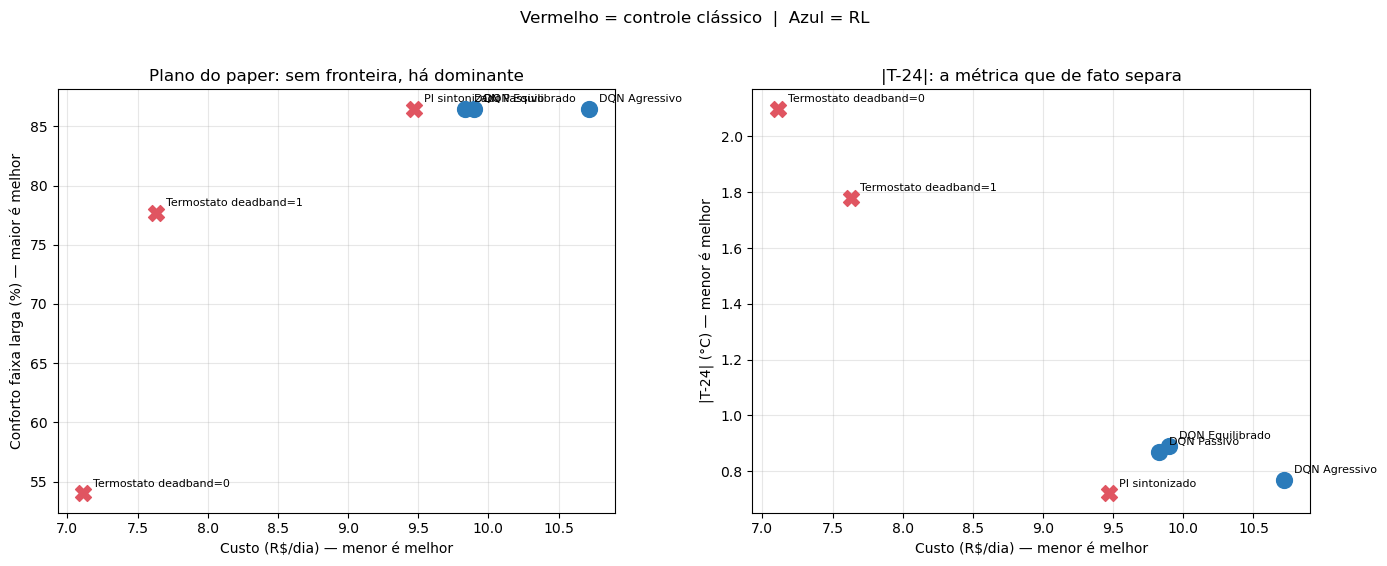

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, (ycol, ylab, melhor) in zip(axes, [
        ("conf_larga_%", "Conforto faixa larga (%)", "maior"),
        ("|T-24|", "|T-24| (°C)", "menor")]):
    for _, r in df.iterrows():
        clas = ("PI" in r.controlador) or ("Termostato" in r.controlador)
        ax.scatter(r["custo_R$"], r[ycol], s=130,
                   marker="X" if clas else "o",
                   color="#e05561" if clas else "#2b7bba", zorder=3)
        ax.annotate(r.controlador, (r["custo_R$"], r[ycol]),
                    textcoords="offset points", xytext=(7, 5), fontsize=8)
    ax.set_xlabel("Custo (R$/dia) — menor é melhor")
    ax.set_ylabel(f"{ylab} — {melhor} é melhor")
    ax.grid(alpha=0.3)
axes[0].set_title("Plano do paper: sem fronteira, há dominante")
axes[1].set_title("|T-24|: a métrica que de fato separa")
fig.suptitle("Vermelho = controle clássico  |  Azul = RL", y=1.02)
plt.tight_layout(); plt.show()

## 3. A penalidade anti-short-cycling é efetiva?

`trocas/h` é um agregado que **esconde** a distribuição. A pergunta correta é:
qual fração dos intervalos entre comutações viola o `d_min` de 36 min?


In [5]:
linhas = []
for nome, (agente, usa_info, cfg) in candidatos.items():
    dfs = [run_episode(agente, factory(cfg)(), s, seed=0, pass_info_to_agent=usa_info) for s in SCEN]
    d = dwell_time_analysis(dfs, cfg)
    if d.get("n_comutacoes"):
        linhas.append({"controlador": nome, "n_comut": d["n_comutacoes"],
                       "mediana_min": d["mediana_min"], "media_min": d["media_min"],
                       "min_min": d["min_min"], "violacoes_%": d["violacoes_pct"]})
dwell = pd.DataFrame(linhas).round(1)
display(dwell)
print(f"\nd_min declarado: {CFG.min_dwell_minutes:.0f} min")
print("A mediana revela o que a média esconde: períodos OFF longos inflam a média.")

,controlador,n_comut,mediana_min,media_min,min_min,violacoes_%
0,PI sintonizado,225,12.0,42.9,12.0,74.7
1,Termostato deadband=0,210,12.0,46.2,12.0,79.0
2,Termostato deadband=1,44,102.0,199.6,12.0,6.8
3,DQN Agressivo,264,12.0,36.0,12.0,83.3
4,DQN Equilibrado,168,12.0,59.8,12.0,71.4
5,DQN Passivo,170,12.0,57.7,12.0,72.9



d_min declarado: 36 min
A mediana revela o que a média esconde: períodos OFF longos inflam a média.


### A correção: restrição dura em vez de penalidade

**Por que a penalidade falha, em uma linha:** ela vale no máximo
`|rho| = 5`, contra ganhos de conforto de até `B + B_c = 14`. É superada no leilão.

Experimente mexer em `rho` abaixo — verá que nenhum valor razoável resolve, porque
o problema é a *natureza* do mecanismo, não sua magnitude.


In [6]:
from dataclasses import replace

cfg_eq = config_for_profile("Equilibrado")
modelo = DQN.load("../models_paper/DQN_Equilibrado_seed0.zip", device="cpu")

def fab(hard, cfg):
    def f():
        e = ClassroomACEnv(config=cfg)
        if hard:
            e = MinDwellWrapper(e)
        return ActionRepeatWrapper(e, repeat=2)
    return f

comp = []
for rho in (-1.0, -5.0, -20.0):          # <-- mexa aqui
    c = replace(cfg_eq, short_cycle_penalty=rho)
    dfs = [run_episode(modelo, fab(False, c)(), s, seed=0) for s in SCEN]
    d = dwell_time_analysis(dfs, c)
    comp.append({"mecanismo": f"penalidade mole (rho={rho:g})",
                 "violacoes_%": d["violacoes_pct"], "mediana_min": d["mediana_min"]})

dfs = [run_episode(modelo, fab(True, cfg_eq)(), s, seed=0) for s in SCEN]
d = dwell_time_analysis(dfs, cfg_eq)
r_hard = evaluate_agent(modelo, fab(True, cfg_eq), SCEN, cfg_eq, seed=0)["summary"]
r_soft = evaluate_agent(modelo, fab(False, cfg_eq), SCEN, cfg_eq, seed=0)["summary"]
comp.append({"mecanismo": "RESTRIÇÃO DURA (MinDwellWrapper)",
             "violacoes_%": d["violacoes_pct"], "mediana_min": d["mediana_min"]})
display(pd.DataFrame(comp).round(1))

print(f"custo da restrição dura:")
print(f"  conforto  {r_soft['comfort_wide_pct']:.1f}% -> {r_hard['comfort_wide_pct']:.1f}%")
print(f"  |T-24|    {r_soft['abs_dev_from_ideal']:.2f} -> {r_hard['abs_dev_from_ideal']:.2f}")
print(f"  energia   {r_soft['energy_kwh_day']:.2f} -> {r_hard['energy_kwh_day']:.2f} kWh/dia")

,mecanismo,violacoes_%,mediana_min
0,penalidade mole (rho=-1),71.4,12.0
1,penalidade mole (rho=-5),71.4,12.0
2,penalidade mole (rho=-20),71.4,12.0
3,RESTRIÇÃO DURA (MinDwellWrapper),6.4,48.0


custo da restrição dura:
  conforto  86.5% -> 86.5%
  |T-24|    0.89 -> 0.97
  energia   10.90 -> 11.31 kWh/dia


**Nota sobre `rho` na célula acima:** variar `rho` na *avaliação* não muda a
política (o agente já está treinado) — muda apenas a recompensa contabilizada.
Para testar de verdade o efeito de `rho` seria preciso **retreinar**:
`python ablation.py --variants completa sem_short_cycling`. O ponto que a célula
demonstra é que a violação é uma propriedade da política aprendida, e só a
restrição estrutural a corrige.


## 4. Rigor estatístico

Com 1 semente nada é afirmável. Treine com `--seeds 0 1 2 3 4` e rode esta célula
para obter ICs, p-valores e tamanhos de efeito.


In [7]:
import glob
por_semente = {}
for path in sorted(glob.glob("../models_paper/DQN_*_seed*.zip")):
    base = os.path.basename(path).replace(".zip", "")
    perfil = base.split("_")[1]
    c = config_for_profile(perfil)
    s = evaluate_agent(DQN.load(path, device="cpu"), factory(c), SCEN, c, seed=0)["summary"]
    por_semente.setdefault(f"DQN {perfil}", []).append(s["abs_dev_from_ideal"])

pi = PIController(CFG, kp=best["kp"], ki=best["ki"])
por_semente["PI sintonizado"] = [
    evaluate_agent(pi, factory(), SCEN, CFG, seed=sd, pass_info_to_agent=True)["summary"]["abs_dev_from_ideal"]
    for sd in (0, 1, 2)
]

n = min(len(v) for v in por_semente.values())
if n < 3:
    print(f"ATENÇÃO: apenas {n} semente(s) por agente. IC não é interpretável.")
    print("Rode: python train.py --timesteps 550000 --seeds 0 1 2 3 4")

from stats_analysis import compare_agents
display(compare_agents(por_semente, metric_name="desvio_ideal", baseline="PI sintonizado"))

ATENÇÃO: apenas 1 semente(s) por agente. IC não é interpretável.
Rode: python train.py --timesteps 550000 --seeds 0 1 2 3 4


,agente,n_sementes,desvio_ideal_media,ic95_inf,ic95_sup,diff_vs_baseline,p_valor,cliffs_delta,efeito
0,DQN Agressivo,1,0.77,0.77,0.77,0.05,0.2528,1.0,grande
1,DQN Equilibrado,1,0.89,0.89,0.89,0.17,0.2528,1.0,grande
2,DQN Passivo,1,0.87,0.87,0.87,0.15,0.2528,1.0,grande
3,PI sintonizado,3,0.72,0.72,0.72,NaN,NaN,NaN,NaN


## 5. O que ainda falta

- **Ablação da recompensa** — `python ablation.py --seeds 0 1 2` (~3 h). Sem ela a
  tese "recompensa > algoritmo" não é verificável.
- **Separar calibração de teste** — a matriz 3×3 é usada para ajustar *e* avaliar.
- **MPC e Q-Learning tabular** — o tabular responde diretamente à dúvida do R1
  sobre necessidade de RL profundo (ver Zha et al. 2021, HNP).
- **BOPTEST / BuildingGym** — validação externa do simulador.

Ver `REVISAO.md` para o mapeamento completo dos pareceres.
